<a href="https://colab.research.google.com/github/ShlokVaibhav/AI_for_Analog_Design/blob/spec_implementation/Analog_Specs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! python --version    # Pyspice works with python  3.9 or lower
!pip install -q gdown

Python 3.12.12


In [2]:
!gdown --id 1jpVKXaw5eiSAVzJvBa_URSY5Sgfi3Dj0 -O lib_90nm.txt

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1jpVKXaw5eiSAVzJvBa_URSY5Sgfi3Dj0
To: /content/lib_90nm.txt
100% 10.1k/10.1k [00:00<00:00, 19.2MB/s]


In [3]:
# Source: (S1) https://stackoverflow.com/questions/72133319/oserror-cannot-load-library-libngspice-so-libngspice-so-on-google-colab
# First answer
!pip install -q condacolab
!pip install matplotlib
!pip install numpy
!pip install scipy
import condacolab
condacolab.install()


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [1]:
# Installing ngspice [S1] but inside the new environment [S2]
!conda install -c conda-forge ngspice-exe
!conda install -c conda-forge ngspice
!conda install -c conda-forge ngspice-lib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: / - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ngspice-exe


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.11.12 |       hbd8a1cb_0         149 KB  conda-forge
    certifi-2025.11.12         |     pyhd8ed1ab_0         153 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    gettext-0.25.1             |       h5888daf_0         525 KB  conda-forge
    gettext-tools-0.25.1       |       h5888daf_0         3.5 MB  conda-forge
    libasprintf-0.25.1         |       h8e693c7_0          52 KB  conda-forge
    libasprintf-devel-0.25.1   |       h8e693c7_0          34 KB  conda-forge
    libgettextpo-0.25.1        |       h5888daf_0         174 KB  conda-forge
    libgettextpo-devel-0.25.1  |       h5888

In [52]:
import os
os.system("ngspice -b -o output.log schematic.spice")

0

Power: 0.236781084mW
Output swing (VCC=5V): 4.52387492V
DC PSRR is: 170.62977039999998dB
DC CMRR is: 139.9081498dB
DC Gain is: 89.3113565dB
UGB is: 14.08MHz
PM is: -13.15°


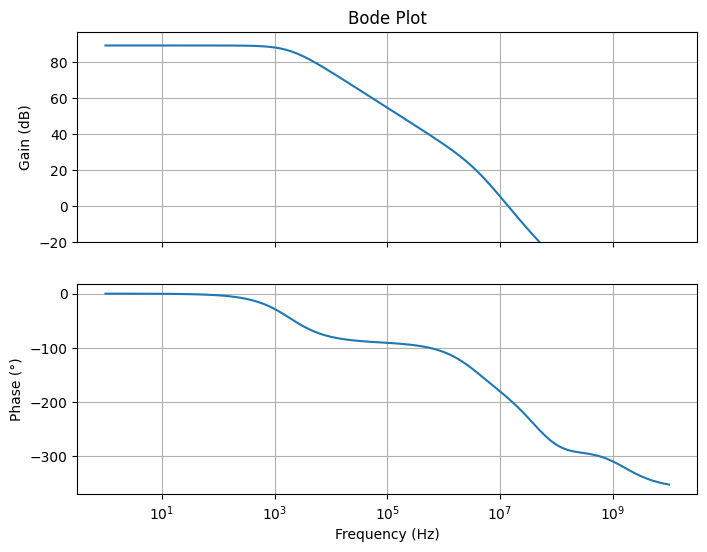

In [53]:
import numpy as np
import matplotlib.pyplot as plt
# Analog specs
def Power():  # returns the power in mW
    with open("power.dat", "r") as f:
      power = 1000*float(f.read().split(' ')[-2])
    f.close()
    return power

def out_swing():  # returns the output swing
    with open("margin.dat", "r") as f:
      out_swing = float(f.read().split(' ')[-2])
    f.close()
    return out_swing

def PSRR():
    PSRR_data = np.loadtxt("PSRR.dat")
    ADC, _,_ = DC_gain()
    return -PSRR_data[0, 1] + ADC

def CMRR():
    CMRR_data = np.loadtxt("CMRR.dat")
    ADC,_,_ = DC_gain()
    return -CMRR_data[0, 1] + ADC

def DC_gain(show=0):
    AC_data = np.loadtxt("AC.dat")
    freq  = AC_data[:, 0]
    gain  = AC_data[:, 1]
    phase = AC_data[:, 3]*180/np.pi - 180
    sign_change_idx = np.where(np.diff(np.sign(gain)) != 0)[0]

    i = sign_change_idx[0]  # first crossover

    # Step 2: Linear interpolation for accurate crossover frequency
    f1, f2 = freq[i], freq[i+1]
    g1, g2 = gain[i], gain[i+1]

    # frequency where gain = 0 dB
    f_gc = f1 + (0 - g1) * (f2 - f1) / (g2 - g1)

    # Step 3: interpolate phase at gain crossover
    p1, p2 = phase[i], phase[i+1]
    phase_gc = p1 + (0 - g1) * (p2 - p1) / (g2 - g1)+180

    if show==1:
      fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

      # Magnitude plot
      ax1.semilogx(freq, gain)
      ax1.set_ylabel("Gain (dB)")
      ax1.grid(True, which="both")
      ax1.set_title("Bode Plot")
      ax1.set_ylim(bottom=-20)

      # Phase plot
      ax2.semilogx(freq, phase)
      ax2.set_xlabel("Frequency (Hz)")
      ax2.set_ylabel("Phase (°)")
      ax2.grid(True, which="both")

      plt.show()
      return
    return gain[0], f_gc/1e6, phase_gc


print("Power: " + str(Power())+"mW")
print("Output swing (VCC=5V): " + str(out_swing())+"V")
print("DC PSRR is: " + str(PSRR())+"dB")
print("DC CMRR is: " + str(CMRR())+"dB")
[Adc, UGB, PM] = DC_gain(0)
print("DC Gain is: " + str(Adc)+"dB")
print("UGB is: " + f"{UGB:.4g}"+"MHz")
print("PM is: " +  f"{PM:.4g}"+"°")
DC_gain(1)


In [ ]:
#The rise fall time specs can be used to find the slew rate
# returns fall time in ns
def Fall_Time(W):
  data = np.loadtxt('Aus.dat')  # your .dat file
  #data = np.loadtxt('I_SUP.dat')  # your .dat file

  # If your file has two columns
  t = data[:, 0]   # first column
  V = data[:, 1]  # second column

  v_min = V.min()
  v_max = V.max()
  v10 = v_min + 0.1*(v_max - v_min)
  v90 = v_min + 0.9*(v_max - v_min)
  tf10 = t[np.where(V <= v10)[0][0]]  # first time V crosses 10%
  tf90 = t[np.where(V <= v90)[0][0]]  # first time V crosses 90%
  tf = (tf10 - tf90)*1e9
  return tf


# returns rise time in ns
def Rise_Time(W):
  data = np.loadtxt('Aus.dat')  # your .dat file
  #data = np.loadtxt('I_SUP.dat')  # your .dat file

  # If your file has two columns
  t = data[:, 0]   # first column
  V = data[:, 1]  # second column

  v_min = V.min()
  v_max = V.max()
  v10 = v_min + 0.1*(v_max - v_min)
  v90 = v_min + 0.9*(v_max - v_min)
  tr10 = t[np.where((V >= v10) & (t > 3e-9))[0][0]]
  tr90 = t[np.where((V >= v90) & (t > 3e-9))[0][0]]
  tr = (tr90 - tr10)*1e9
  return tr

